# Who should get Visa QR Pay first?

Target audiences for the QR Pay launch, built from card behaviour in the last 6 months (Jan-Jun 2026) and the
readiness model (`readiness_model.ipynb`). This notebook answers:

1. **Audience sizes**: who types card numbers today, who is about to start paying online, who to skip.
2. **Profile of the typers**: what, where, on which device and when they type the card number (campaign message).
3. **Audiences x personas**: which behavioural types sit in each audience.
4. **Heavy vs light typers**: in which order to contact audience A.
5. **New cards**: how many arrive each month and what they do in their first months (QR at card issuance).
6. **Inputs for the ROI simulation** (`models.py`): data-based sizes and rates instead of assumptions.

**Audiences** (Polish cards, active in at least 3 of the 6 months):

| Code | Audience | Rule |
|---|---|---|
| A | Mostly typing | paid online, and at least half of the online card payments were a typed card number |
| D | Sometimes typing | paid online, typed some but less than half |
| F | Never typing | paid online, never typed (already one-click) |
| C | Ready to start | never paid online since Jan 2025, in the model's top 20% |
| E | Not ready | never paid online, below the top 20% (or too little activity to score) |
| L | Lapsed | paid online before 2026 but not in the last 6 months |

**New cards** (first seen in the last 3 months) are shown as an overlay across audiences.
Everything shown is an aggregate of at least 30 cards; categories, never single merchants. Data are synthetic.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

import readiness as rd

TODAY = 18  # Jul 2026: window Jan-Jun 2026
MIN_CARDS = 30
READY_TOP = 0.2  # model top share that forms audience C

con = rd.connect()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pct = mtick.PercentFormatter(100)

def safe(df, cards_col="cards"):
    return df[df[cards_col] >= MIN_CARDS].copy()

## 1. Audience sizes

In [2]:
cards = rd.all_card_window(con, TODAY)
scored, check = rd.train_and_score(con, TODAY)
print(f"model check on Apr 2026: AUC {check['auc']:.3f}, predicted {check['predicted']:.2%} vs actual {check['actual']:.2%}")

ready_cut = np.quantile(scored.p, 1 - READY_TOP)
cards = cards.merge(scored[["card", "p"]], on="card", how="left")
never_online = cards.first_online_m.isna()
online_6m = cards.n_online > 0
typed_share = cards.n_typed / cards.n_online.where(online_6m)

cards["audience"] = np.select(
    [online_6m & (typed_share >= 0.5),
     online_6m & (cards.n_typed > 0),
     online_6m,
     never_online & (cards.p >= ready_cut),
     never_online],
    ["A mostly typing", "D sometimes typing", "F never typing", "C ready to start", "E not ready"],
    default="L lapsed")
cards["new_card"] = cards.first_m >= TODAY - 3

aud = cards.groupby("audience").agg(
    cards=("card", "size"),
    online_tx=("n_online", "sum"),
    typed_tx=("n_typed", "sum"),
    new_cards=("new_card", "sum"),
    mostly_wallet_share=("wallet_share", lambda s: (s >= 0.5).mean()),
    expected_starters_3m=("p", "sum"),
)
aud["share_of_cards"] = aud.cards / aud.cards.sum()
aud["share_of_typed_tx"] = aud.typed_tx / aud.typed_tx.sum()
aud["online_tx_per_card_month"] = aud.online_tx / aud.cards / 6
aud["typed_tx_per_card_month"] = aud.typed_tx / aud.cards / 6
aud = safe(aud.reset_index())
aud

model check on Apr 2026: AUC 0.757, predicted 4.92% vs actual 4.92%


,audience,cards,online_tx,typed_tx,new_cards,mostly_wallet_share,expected_starters_3m,share_of_cards,share_of_typed_tx,online_tx_per_card_month,typed_tx_per_card_month
0,A mostly typing,190336,"4,184,494.00","3,223,115.00",4581,0.71,0.00,0.22,0.80,3.66,2.82
1,C ready to start,57628,0.00,0.00,3370,0.43,"8,161.53",0.07,0.00,0.00,0.00
2,D sometimes typing,150758,"3,835,737.00","806,112.00",1476,0.48,0.00,0.17,0.20,4.24,0.89
3,E not ready,281853,0.00,0.00,3673,0.04,"6,653.57",0.32,0.00,0.00,0.00
4,F never typing,148595,"1,134,219.00",0.00,1252,0.25,0.00,0.17,0.00,1.27,0.00
5,L lapsed,48998,0.00,0.00,0,0.27,0.00,0.06,0.00,0.00,0.00


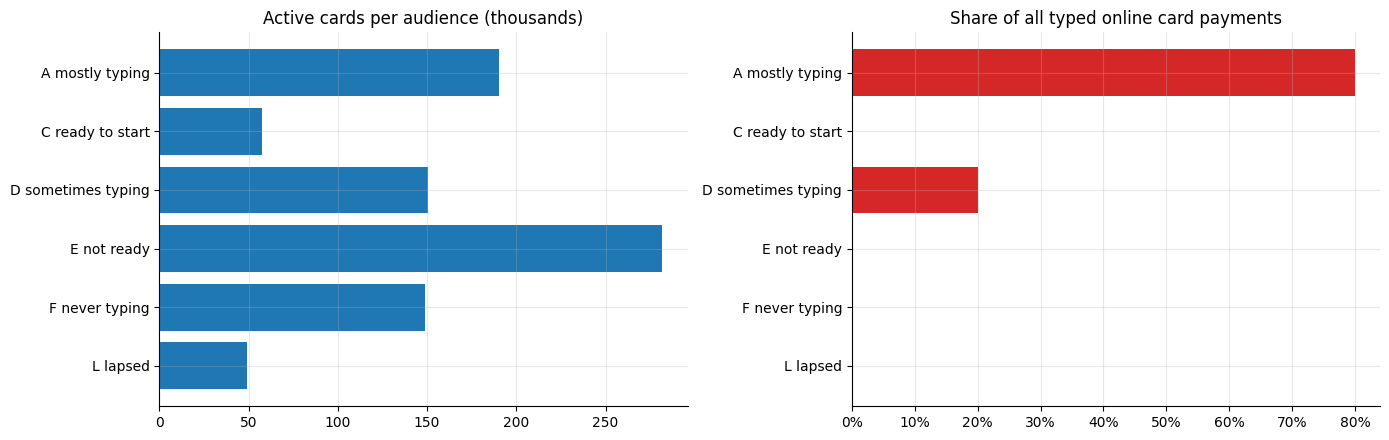

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
a = aud.set_index("audience").sort_index()
axes[0].barh(a.index, a.cards / 1000)
axes[0].invert_yaxis()
axes[0].set_title("Active cards per audience (thousands)")
axes[1].barh(a.index, a.share_of_typed_tx * 100, color="C3")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(pct)
axes[1].set_title("Share of all typed online card payments")
plt.tight_layout()

## 2. Profile of audience A: where do they type the card number?

Online card payments (excluding money transfers / top-ups) of audience A cards in Jan-Jun 2026.

In [4]:
a_cards = cards.loc[cards.audience == "A mostly typing", ["card"]]
con.register("a_cards", a_cards)
IS_ONLINE = f"(cp_flag = 0 AND mrch_catg_cd NOT IN {rd.NOT_SHOPPING_MCC})"
LOCAL_HOUR = "((ts % 1000000) // 10000 + CASE WHEN month % 100 BETWEEN 4 AND 10 THEN 2 ELSE 1 END) % 24"
parts, cat_cards = [], []
for b in range(rd.N_BUCKETS):
    # distinct cards typing per category (a card lives in exactly one bucket, so bucket counts add up)
    cat_cards.append(con.sql(f'''
        SELECT ({rd.MACRO}) AS category, count(DISTINCT card) AS cards
        FROM read_parquet('{rd.SLIM}/bucket={b}/*.parquet') t
        SEMI JOIN a_cards USING (card)
        WHERE {IS_ONLINE} AND entry_mode = 'Manual key entry'
          AND month BETWEEN {rd.yyyymm(TODAY - 6)} AND {rd.yyyymm(TODAY - 1)}
        GROUP BY 1
    ''').df())
    parts.append(con.sql(f'''
        SELECT ({rd.MACRO}) AS category,
               channel_flg = 'mobile' AS on_phone,
               entry_mode = 'Manual key entry' AS typed,
               merchant_pl,
               CASE WHEN {LOCAL_HOUR} < 6 THEN '00-06' WHEN {LOCAL_HOUR} < 12 THEN '06-12'
                    WHEN {LOCAL_HOUR} < 18 THEN '12-18' ELSE '18-24' END AS time_of_day,
               count(*) AS tx, sum(amt) AS amount
        FROM read_parquet('{rd.SLIM}/bucket={b}/*.parquet') t
        SEMI JOIN a_cards USING (card)
        WHERE {IS_ONLINE} AND month BETWEEN {rd.yyyymm(TODAY - 6)} AND {rd.yyyymm(TODAY - 1)}
        GROUP BY ALL
    ''').df())
a_tx = pd.concat(parts, ignore_index=True)
cards_cat = pd.concat(cat_cards).groupby("category").cards.sum()
a_typed = a_tx[a_tx.typed]
print(f"audience A: {a_cards.shape[0]:,} cards, {a_tx.tx.sum():,.0f} online payments, "
      f"{a_typed.tx.sum():,.0f} typed ({a_typed.tx.sum() / a_tx.tx.sum():.0%})")

audience A: 190,336 cards, 4,184,494 online payments, 3,223,115 typed (77%)


In [5]:
by_cat = a_tx.groupby(["category", "typed"]).agg(tx=("tx", "sum"), amount=("amount", "sum")).unstack("typed").fillna(0)
by_cat.columns = [f"{m}_{'typed' if t else 'one_click'}" for m, t in by_cat.columns]
by_cat["typed_tx"] = by_cat.tx_typed
by_cat["share_of_a_typed_pct"] = by_cat.tx_typed / by_cat.tx_typed.sum() * 100
by_cat["typed_within_category_pct"] = by_cat.tx_typed / (by_cat.tx_typed + by_cat.tx_one_click) * 100
by_cat["avg_typed_amount"] = by_cat.amount_typed / by_cat.tx_typed.replace(0, np.nan)
by_cat["cards_typing"] = cards_cat
pl_share = a_typed.groupby("category").apply(lambda d: d.loc[d.merchant_pl, "tx"].sum() / d.tx.sum(), include_groups=False)
by_cat["polish_merchant_pct"] = pl_share * 100
by_cat = safe(by_cat.reset_index(), "cards_typing").sort_values("typed_tx", ascending=False)
cols = ["category", "typed_tx", "share_of_a_typed_pct", "typed_within_category_pct", "cards_typing",
        "avg_typed_amount", "polish_merchant_pct"]
by_cat[cols]

,category,typed_tx,share_of_a_typed_pct,typed_within_category_pct,cards_typing,avg_typed_amount,polish_merchant_pct
10,marketplace_general,563707,17.49,94.74,87792,269.38,75.75
14,taxi,544764,16.90,89.34,58952,42.39,49.59
11,other,357772,11.10,80.43,89870,306.47,52.34
12,public_transport,341775,10.60,92.46,58417,81.21,87.02
2,digital_content,211703,6.57,27.14,64307,141.19,21.58
5,fast_food,200421,6.22,94.77,47589,114.19,96.74
4,fashion_sport,171384,5.32,96.75,55455,603.02,61.73
0,bills_telecom_edu,165989,5.15,88.32,51375,370.32,87.44
3,entertainment_betting,155265,4.82,76.89,40072,261.97,48.22
13,restaurants_bars,147504,4.58,91.99,32061,151.79,40.32


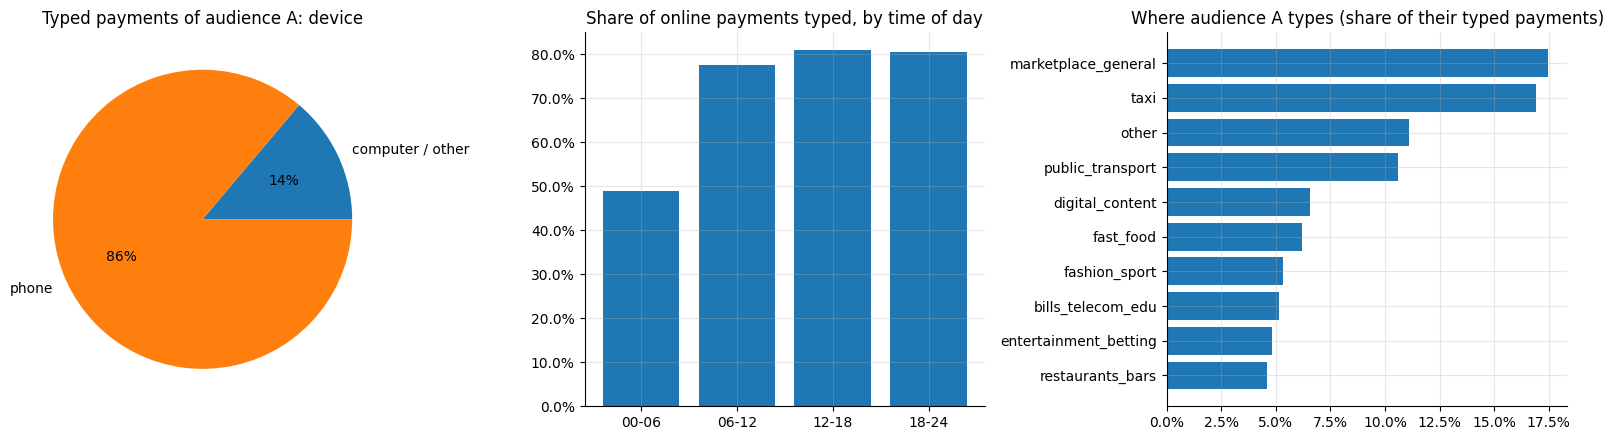

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
dev = a_typed.groupby("on_phone").tx.sum()
axes[0].pie(dev.values, labels=["computer / other" if not k else "phone" for k in dev.index], autopct="%1.0f%%")
axes[0].set_title("Typed payments of audience A: device")
tod = a_tx.groupby(["time_of_day", "typed"]).tx.sum().unstack()
tod_share = tod[True] / tod.sum(axis=1) * 100
axes[1].bar(tod_share.index, tod_share.values)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_title("Share of online payments typed, by time of day")
top = by_cat.head(10).sort_values("typed_tx")
axes[2].barh(top.category, top.share_of_a_typed_pct)
axes[2].xaxis.set_major_formatter(pct)
axes[2].set_title("Where audience A types (share of their typed payments)")
plt.tight_layout()

## 3. Audiences x personas

In [7]:
assign = rd.fit_personas(rd.load_snapshot(6))
cards["persona"] = assign(cards)
cross = cards.groupby(["audience", "persona"]).size().rename("cards").reset_index()
cross = safe(cross)
table = cross.pivot(index="persona", columns="audience", values="cards").fillna(0).astype(int)
share = table.div(table.sum(axis=0), axis=1) * 100
print("cards")
display(table)
print("% of each audience")
share.round(1)

cards


audience,A mostly typing,C ready to start,D sometimes typing,E not ready,F never typing,L lapsed
persona,,,,,,
active all-rounders,18039,13259,26660,54188,34502,9969
everyday grocery,15721,6976,20202,107284,36295,10657
home & car,12072,4252,11656,43200,15724,6339
mall shoppers,11834,4281,10325,59347,17581,6864
phone-first city,116069,26117,71791,14001,39927,12751
travellers,16601,2743,10124,3833,4566,2418


% of each audience


audience,A mostly typing,C ready to start,D sometimes typing,E not ready,F never typing,L lapsed
persona,,,,,,
active all-rounders,9.50,23.00,17.70,19.20,23.20,20.30
everyday grocery,8.30,12.10,13.40,38.10,24.40,21.70
home & car,6.30,7.40,7.70,15.30,10.60,12.90
mall shoppers,6.20,7.40,6.80,21.10,11.80,14.00
phone-first city,61.00,45.30,47.60,5.00,26.90,26.00
travellers,8.70,4.80,6.70,1.40,3.10,4.90


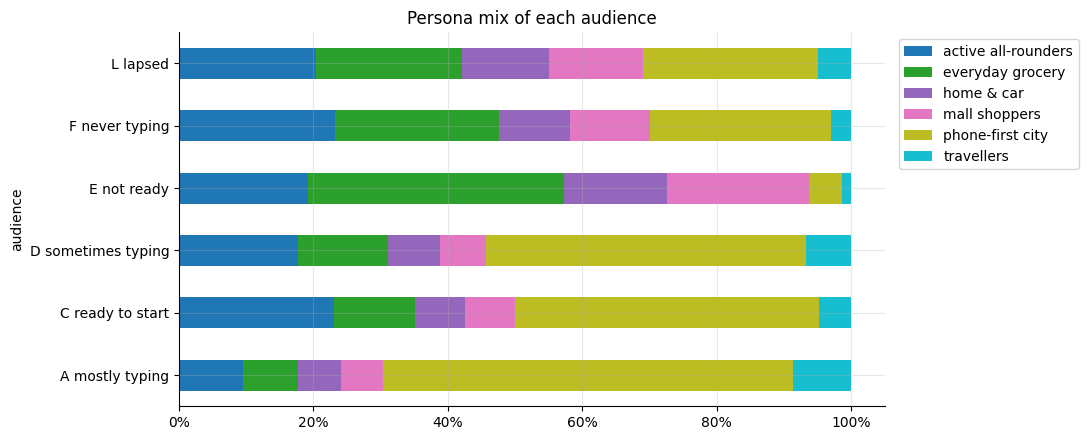

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
share.T.plot.barh(stacked=True, ax=ax, colormap="tab10")
ax.xaxis.set_major_formatter(pct)
ax.set_title("Persona mix of each audience")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()

## 4. Heavy vs light typers in audience A: contact order

,cards,typed_tx,min_typed_per_month,max_typed_per_month,mostly_wallet_share,cum_share_of_typed_pct
top 10%,19034,"1,382,299.00",7.17,598.83,0.94,42.89
top 20%,19033,"647,125.00",4.50,7.17,0.93,62.96
top 30%,19034,"426,891.00",3.00,4.50,0.91,76.21
top 40%,19033,"288,797.00",2.00,3.00,0.87,85.17
top 50%,19034,"191,298.00",1.33,2.00,0.80,91.10
top 60%,19033,"122,301.00",0.83,1.33,0.71,94.90
top 70%,19034,"75,676.00",0.50,0.83,0.61,97.25
top 80%,19033,"45,387.00",0.33,0.50,0.53,98.66
top 90%,19034,"24,307.00",0.17,0.33,0.43,99.41
top 100%,19034,"19,034.00",0.17,0.17,0.40,100.00


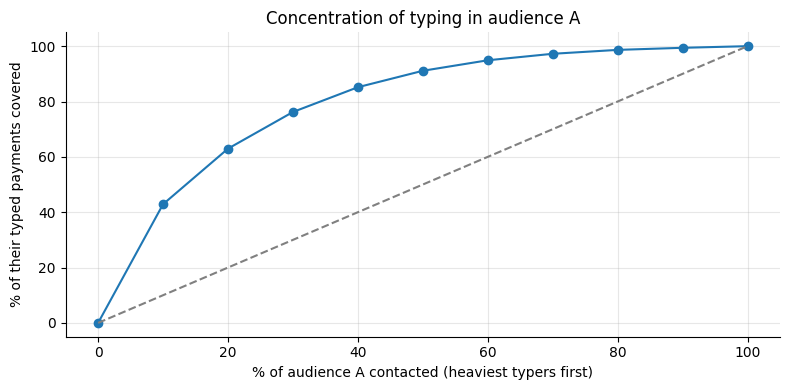

In [9]:
a = cards[cards.audience == "A mostly typing"].copy()
a["typed_per_month"] = a.n_typed / 6
a["decile"] = pd.qcut(a.n_typed.rank(method="first"), 10, labels=False)
dec = a.groupby("decile").agg(cards=("card", "size"), typed_tx=("n_typed", "sum"),
                              min_typed_per_month=("typed_per_month", "min"),
                              max_typed_per_month=("typed_per_month", "max"),
                              mostly_wallet_share=("wallet_share", lambda s: (s >= 0.5).mean())
                              ).sort_index(ascending=False)
dec["cum_share_of_typed_pct"] = dec.typed_tx.cumsum() / dec.typed_tx.sum() * 100
dec.index = [f"top {10 * (i + 1)}%" for i in range(len(dec))]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(0, 101, 10)
ax.plot(x, [0] + list(dec.cum_share_of_typed_pct), "o-")
ax.plot([0, 100], [0, 100], color="grey", ls="--")
ax.set_xlabel("% of audience A contacted (heaviest typers first)")
ax.set_ylabel("% of their typed payments covered")
ax.set_title("Concentration of typing in audience A")
plt.tight_layout()
dec

## 5. New cards: the moment of issuance

Cards by the month they first appear. For each monthly cohort: size, share paying by phone in store in the first
month, share with a first online payment within 1 and 3 months, and how that first online payment was made.

,cohort_m,cards,wallet_first_month,online_first_month,online_within_3m,first_online_typed,month
0,3,36158,0.24,0.32,0.42,0.66,2025-04-01
1,4,32367,0.26,0.32,0.43,0.67,2025-05-01
2,5,30131,0.29,0.33,0.44,0.69,2025-06-01
3,6,30634,0.30,0.34,0.46,0.71,2025-07-01
4,7,28351,0.31,0.35,0.46,0.71,2025-08-01
5,8,27752,0.33,0.37,0.48,0.71,2025-09-01
6,9,27504,0.32,0.38,0.51,0.71,2025-10-01
7,10,24939,0.32,0.42,0.53,0.72,2025-11-01
8,11,24212,0.33,0.41,0.53,0.73,2025-12-01
9,12,23126,0.34,0.40,0.53,0.72,2026-01-01


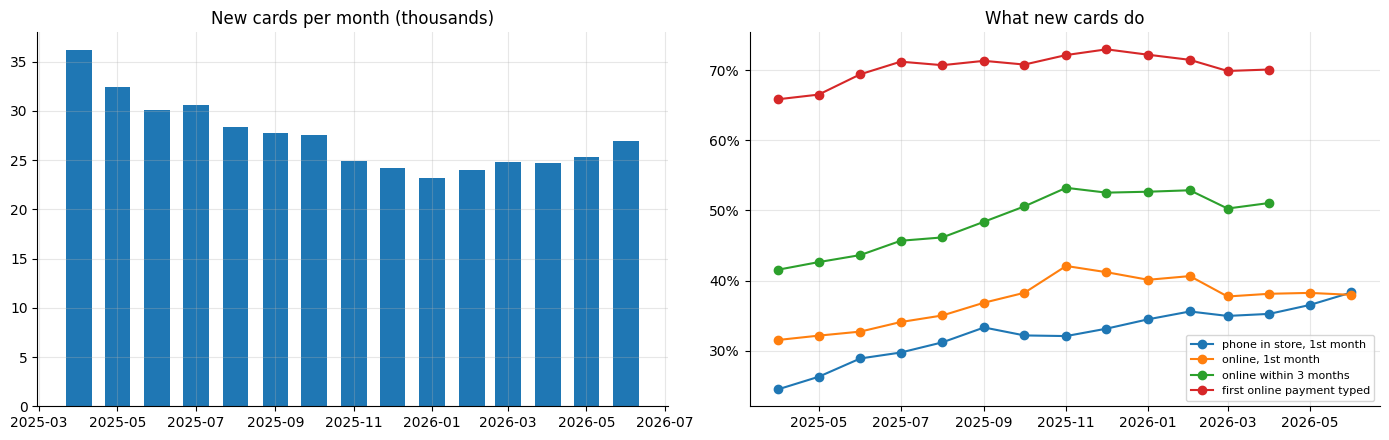

In [10]:
cohorts = con.sql(f'''
    WITH first AS (
        SELECT card, min(m) AS first_m,
               min(m) FILTER (WHERE n_online > 0) AS first_online_m,
               min(m) FILTER (WHERE n_wallet_store > 0) AS first_wallet_m
        FROM panel GROUP BY card
    )
    SELECT f.first_m AS cohort_m, count(*) AS cards,
           avg(coalesce(f.first_wallet_m = f.first_m, FALSE)::INT) AS wallet_first_month,
           avg(coalesce(f.first_online_m = f.first_m, FALSE)::INT) AS online_first_month,
           avg(coalesce(f.first_online_m <= f.first_m + 2, FALSE)::INT) AS online_within_3m,
           avg((o.first_mode = 'Manual key entry')::INT) FILTER (WHERE f.first_online_m <= f.first_m + 2) AS first_online_typed
    FROM first f LEFT JOIN read_parquet('{rd.FIRST_ONLINE}/*.parquet') o USING (card)
    WHERE f.first_m >= 3
    GROUP BY 1 ORDER BY 1
''').df()
cohorts["month"] = pd.to_datetime([f"{rd.yyyymm(m)}" for m in cohorts.cohort_m], format="%Y%m")
cohorts.loc[cohorts.cohort_m > TODAY - 3, ["online_within_3m", "first_online_typed"]] = np.nan  # not fully observed
cohorts = safe(cohorts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(cohorts.month, cohorts.cards / 1000, width=20)
axes[0].set_title("New cards per month (thousands)")
for col, label in [("wallet_first_month", "phone in store, 1st month"), ("online_first_month", "online, 1st month"),
                   ("online_within_3m", "online within 3 months"), ("first_online_typed", "first online payment typed")]:
    axes[1].plot(cohorts.month, cohorts[col] * 100, "o-", label=label)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_title("What new cards do")
axes[1].legend(fontsize=8)
plt.tight_layout()
cohorts

## 6. Inputs for the ROI simulation

Data-based replacements for assumptions in `models.py`. Sizes are given both as counts in this data sample and as a
**share of active cards**, so they can be scaled to the real Polish card base.

In [11]:
active_total = len(cards)
mature = cohorts.dropna(subset=["online_within_3m"])
roi_inputs = {
    "as_of": "Jan-Jun 2026 window, snapshot Jul 2026",
    "active_cards_in_sample": int(active_total),
    "audiences": {
        r.audience: {
            "cards": int(r.cards),
            "share_of_active_cards": round(r.share_of_cards, 4),
            "share_of_typed_online_payments": round(r.share_of_typed_tx, 4),
            "online_payments_per_card_month": round(r.online_tx_per_card_month, 2),
            "typed_payments_per_card_month": round(r.typed_tx_per_card_month, 2),
            "mostly_phone_in_store_share": round(r.mostly_wallet_share, 3),
        } for r in aud.itertuples()
    },
    "ready_to_start": {
        "definition": f"never online since Jan 2025, model top {READY_TOP:.0%}",
        "expected_first_online_payments_3m": float(aud.set_index("audience").loc["C ready to start", "expected_starters_3m"]),
        "expected_start_rate_3m": float(cards.loc[cards.audience == "C ready to start", "p"].mean()),
    },
    "new_cards": {
        "per_month_avg": float(cohorts.cards.mean()),
        "per_month_share_of_active_cards": round(cohorts.cards.mean() / active_total, 4),
        "online_within_3_months": round(float(mature.online_within_3m.mean()), 3),
        "first_online_payment_typed": round(float(mature.first_online_typed.mean()), 3),
    },
    "retention_effect_of_one_click_first_payment_pp": {
        "conservative_same_category": 4.2,
        "overall": 14.0,
        "source": "wallet_online.ipynb, share paying online in 3+ of the next 6 months",
    },
}
json.dumps(roi_inputs["new_cards"], indent=1)

'{\n "per_month_avg": 27393.533333333333,\n "per_month_share_of_active_cards": 0.0312,\n "online_within_3_months": 0.486,\n "first_online_payment_typed": 0.704\n}'

In [12]:
export = {
    "roi_inputs": roi_inputs,
    "audiences": aud.round(4).to_dict(orient="records"),
    "audience_a_categories": by_cat[cols].round(3).to_dict(orient="records"),
    "audience_a_device_typed_tx": {("phone" if k else "computer_other"): int(v) for k, v in dev.items()},
    "audience_a_typed_share_by_time_of_day_pct": tod_share.round(1).to_dict(),
    "audience_persona_cards": cross.to_dict(orient="records"),
    "audience_a_deciles": dec.reset_index(names="group").round(3).to_dict(orient="records"),
    "new_card_cohorts": cohorts.drop(columns="month").round(4).to_dict(orient="records"),
}
out = Path("results") / "target_audiences.json"
out.write_text(json.dumps(export, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
print(f"saved {out}")

saved results\target_audiences.json


## Verdict (Jan-Jun 2026, 878k active Polish cards)

| Audience | Cards | Share of cards | Share of typed online payments | Role for QR Pay |
|---|---|---|---|---|
| **A mostly typing** | 190k | 22% | **80%** | wave 1: QR replaces 2.8 typed payments per card per month |
| **C ready to start** | 58k | 7% | - | wave 2: ~8.2k expected first online payments in 3 months (14%); make it a QR payment |
| **New cards** (overlay) | ~27k per month | 3% per month | - | QR at issuance: 49% pay online within 3 months and **70% of those first online payments are typed** |
| D sometimes typing | 151k | 17% | 20% | wave 3 |
| E not ready | 282k | 32% | - | skip (the other 45% of expected starters, spread thin) |
| F never typing | 149k | 17% | 0% | skip: already one-click |
| L lapsed | 49k | 6% | - | skip |

**Profile of audience A (campaign message)**
- 86% of their typed payments are made **on a phone**; among the heaviest typers (top 20%) 93% pay mostly by
  phone in store. QR Pay must work from the phone / banking app, not only from the plastic card.
- Where they type: online marketplaces 17%, taxi / ride-hailing 17%, public transport tickets 11%, digital content 7%,
  fast food / delivery 6%, fashion 5%. Inside these categories 89-97% of their payments are typed.
- Typing happens all day (77-81% of online payments between 06:00 and 24:00); at night automatic renewals dominate.
- Marketplaces, transport tickets and food delivery are mostly Polish merchants (76-97%): natural first QR merchants.

**Contact order in A:** the heaviest 20% of typers (38k cards, 4.5+ typed payments per month) make **63%** of the
audience's typed payments; the top 40% make 85%.

**Personas:** 61% of audience A and 45% of audience C are "phone-first city"; audience E is dominated by
"everyday grocery" (38%).

**ROI inputs** are exported in `results/target_audiences.json` (`roi_inputs`): audience shares of active cards,
payments per card per month, expected starters, new cards per month and the retention effect (+4 pp conservative,
+14 pp overall).

**Limitations:** synthetic data; the model predicts who is likely to start, not who can be persuaded; a person can
hold several cards; "never online" can still mean paying online with BLIK or another card.
